In [1]:
import matplotlib.pyplot as plt
import scienceplots
# plt.style.use('science')
plt.style.use(['science', 'nature', 'grid'])

from matplotlib.lines import Line2D

import string
import numpy as np
from scipy.interpolate import interp1d
import pandas as pd
import json

from LoadTSV import read_solution_file, interpolate_solution, sol_final

In [2]:
WIDTH = 6.0 
HEIGHT = 2.5 #5.0

plt.rcParams.update({
    "figure.figsize": (WIDTH, HEIGHT),
    "font.size": 10,           # Matches thesis 10pt
    "axes.labelsize": 10,
    "legend.fontsize": 8,      # Slightly smaller for legends
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.linewidth": 1,
    "lines.markersize": 4,
    "savefig.bbox": 'tight',   # Ensures no labels are cut off
    "savefig.pad_inches": 0.05
})

labels = string.ascii_lowercase

In [3]:
colors = ['blue', 'orange', 'green', 'red', 'purple', 'black']

In [4]:
Moments = [4, 5, 8, 9]
closure_vec = ["Gram", "ExtGram", "Grad"]
Kn = 1.0
source = "relaxation_source"
T_end = 25.0
base_tree_level = 10
polydeg = 1

# Initial condition parameters for the RH problem
Mach = np.array([1.4, 2.0])

rho_L = 1.0
rho_R = lambda Ma: (2*Ma**2) / (Ma**2 + 1)
v_L = lambda Ma: np.sqrt(3) * Ma
v_R = lambda Ma: np.sqrt(3) / 2 * (Ma**2 + 1) / Ma
theta_L = 1.0
theta_R = lambda Ma: (3*Ma**2 - 1) * (Ma**2 + 1) / (4 * Ma**2)

x_lower = -20.0
x_upper = 100.0

In [5]:
theta_R(1.4), theta_R(2.0)

(1.8424489795918366, 3.4375)

In [6]:
filename_moments = lambda M, closure, rho_L, rho_R, v_L, v_R, theta_L, theta_R: f"../out/ShockTube/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"

In [7]:
# DVM
N = 500
c_l = -10.0
c_u = 10.0
base_tree_level_DVM = 10

In [8]:
linestyles = ['--', '-', ':']
linewidth = 1.5

/tmp/ipykernel_13943/360715752.py:41: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()
/tmp/ipykernel_13943/360715752.py:41: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()
/tmp/ipykernel_13943/360715752.py:41: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()
/tmp/ipykernel_13943/360715752.py:41: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()
/tmp/ipykernel_13943/360715752.py:41: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()
/tmp/ipykernel_13943/360715752.py:41: Us

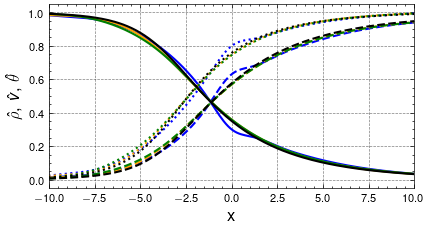

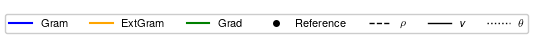

In [10]:
for i, Ma in enumerate(Mach):
    for M in Moments:
        fig, axs = plt.subplots(figsize=(.75*WIDTH, HEIGHT))
        for j, closure in enumerate(closure_vec):
            if Ma == 2.0 and closure == 'Grad' and M == 8:
                continue    # diverged
            elif Ma == 2.0 and M == 9 and closure in ['Gram', 'Grad']:
                continue # diverged
            file = filename_moments(M, closure, rho_L, rho_R(Ma), v_L(Ma), v_R(Ma), theta_L, theta_R(Ma))
            x, u, _ = sol_final(file)
            rho = u[:, 0]
            v = u[:, 1] / rho
            p = (u[:, 2] - rho * v**2) # ?1/2 * u[:, 2]
            theta = p / rho

            axs.plot(x, (rho - rho_L) / (rho_R(Ma) - rho_L), color=colors[j], ls=linestyles[0], lw=linewidth)
            axs.plot(x, (v - v_R(Ma)) / (v_L(Ma) - v_R(Ma)), color=colors[j], ls=linestyles[1], lw=linewidth)
            axs.plot(x, (theta - theta_L) / (theta_R(Ma) - theta_L), color=colors[j], ls=linestyles[2], lw=linewidth)

        # DVM solution
        data_DVM = pd.read_csv(f'../out/ShockTube/DVM/DVM_solution_N{N}_c_l{c_l}_c_u{c_u}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R(Ma)}_v_L{v_L(Ma)}_v_R{v_R(Ma)}_theta_L{theta_L}_theta_R{theta_R(Ma)}_base_tree_level{base_tree_level_DVM}_polydeg{polydeg}_x_left{x_lower}_x_right{x_upper}_rho_v_p.csv')

        x_DVM = data_DVM['x'].to_numpy()
        rho_DVM = data_DVM['rho'].to_numpy()
        v_DVM = data_DVM['v'].to_numpy()
        p_DVM = data_DVM['p'].to_numpy()
        theta_DVM = p_DVM / rho_DVM
        q_DVM = data_DVM['q'].to_numpy()

        axs.plot(x_DVM, (rho_DVM - rho_L) / (rho_R(Ma) - rho_L), color=colors[-1], ls=linestyles[0], lw=linewidth)
        axs.plot(x_DVM, (v_DVM - v_R(Ma)) / (v_L(Ma) - v_R(Ma)), color=colors[-1], ls=linestyles[1], lw=linewidth)
        axs.plot(x_DVM, (theta_DVM - theta_L) / (theta_R(Ma) - theta_L), color=colors[-1], ls=linestyles[2], lw=linewidth)
        
        axs.set_xlim(-10, 10)
        axs.set_ylim(-0.05, 1.05)
        axs.set_xlabel('x', fontsize=12)
        axs.set_ylabel(r'$\hat{\rho}, \, \hat{v}, \, \hat{\theta}$', fontsize=12)

        fig.tight_layout()
        fig.savefig(f'../out/Figures/ShockStructure/ShockStructure_Ma{Ma}_M{M}.pdf', bbox_inches='tight')
        fig.show()

# To save JUST the legend as a separate file
fig_leg = plt.figure(figsize=(WIDTH, 0.5))
ax_leg = fig_leg.add_subplot(111)
ax_leg.axis('off')
# Grab handles from one of your existing axes
closure_elements = [Line2D([0], [0], color=colors[i], lw=linewidth, label=closure_vec[i]) for i in range(len(closure_vec))] + [Line2D([0], [0], color='black', marker='o', lw=0, label='Reference')] + [Line2D([0], [0], ls=linestyles[i], color='black', label=label_) for i, label_ in enumerate(['$\\rho$', '$v$', '$\\theta$'])] 
ax_leg.legend(handles=closure_elements, loc='center', ncol=7)
fig_leg.savefig('../out/Figures/ShockStructure/legend_horizontal_ShockStructure.pdf')

### Problems of Grad

In [ ]:
Moments = [4, 6, 8, 9]
closure = "Grad"
Kn = 1.0
source = "relaxation_source"
T_end = 25.0
base_tree_level = 10
polydeg = 1

# Initial condition parameters for the RH problem
Mach = np.array([1.4])#, 2.0])

rho_L = 1.0
rho_R = lambda Ma: (2*Ma**2) / (Ma**2 + 1)
v_L = lambda Ma: np.sqrt(3) * Ma
v_R = lambda Ma: np.sqrt(3) / 2 * (Ma**2 + 1) / Ma
theta_L = 1.0
theta_R = lambda Ma: (3*Ma**2 - 1) * (Ma**2 + 1) / (4 * Ma**2)

x_lower = -20.0
x_upper = 100.0

FileNotFoundError: [Errno 2] No such file or directory: '../out/ShockTube/Moments/gram_solution_M9_closureGrad_Kn1.0_sourcerelaxation_source_T_end25.0_rho_L1.0_rho_R1.6_v_L3.4641016151377544_v_R2.1650635094610964_theta_L1.0_theta_R3.4375_base_tree_level10_polydeg1_cons.tsv'

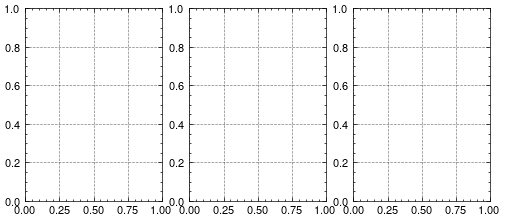

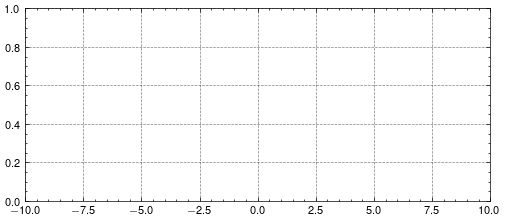

In [ ]:
for i, Ma in enumerate(Mach):
    fig, axs = plt.subplots(1, 3)
    fig_prim, ax_prim = plt.subplots()
    ax_prim.set_xlim(-10, 10)
    for j, M in enumerate(Moments):
            file = filename_moments(M, closure, rho_L, rho_R(Ma), v_L(Ma), v_R(Ma), theta_L, theta_R(Ma))
            x, u, _ = sol_final(file)
            rho = u[:, 0]
            v = u[:, 1] / rho
            p = (u[:, 2] - rho * v**2) # ?1/2 * u[:, 2]
            theta = p / rho

            axs[0].plot(x, (rho - rho_L) / (rho_R(Ma) - rho_L), color=colors[j])
            axs[1].plot(x, (v - v_R(Ma)) / (v_L(Ma) - v_R(Ma)), color=colors[j])
            axs[2].plot(x, (theta - theta_L) / (theta_R(Ma) - theta_L), color=colors[j])

            file_prim = f"../out/ShockTube/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R(Ma)}_v_L{v_L(Ma)}_v_R{v_R(Ma)}_theta_L{theta_L}_theta_R{theta_R(Ma)}_base_tree_level{base_tree_level}_polydeg{polydeg}_prim.tsv"
            x, w, _ = sol_final(file_prim)
            q = w[:, 3]
            ax_prim.plot(x, q, color=colors[j], label=f'M={M}')
            ax_prim.legend()
            ax_prim.set_xlabel('x')
            ax_prim.set_ylabel('Q')
        
    [ax.set_xlim(-10, 10) for ax in axs]
    [ax.set_ylim(-0.05, 1.05) for ax in axs]
    [ax.set_xlabel('x') for ax in axs]
    [ax.set_ylabel(label) for ax, label in zip(axs, ['$\\rho$', '$v$', '$\\theta$'])]
    # [axs[i].set_title(f'{labels[i]})', loc='left') for i in range(3)]

    closure_elements = [Line2D([0], [0], color=colors[j], lw=linewidth, label=f'M={M}') for j, M in enumerate(Moments)]
    leg = fig.legend(
        handles=closure_elements, 
        loc='upper center', 
        bbox_to_anchor=(0.5, 1.06), 
        ncol=5, 
        # frameon=True,
        columnspacing=1.0 # Adjust spacing between columns
    )

    fig.tight_layout()
    fig.savefig(f'../out/Figures/ShockStructure/ShockStructure_Ma{Ma}_M{M}_Grad.pdf', bbox_inches='tight')
    fig.show()